<a href="https://colab.research.google.com/github/fabiocf12/MPA-MLF-exercises/blob/main/lab2_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

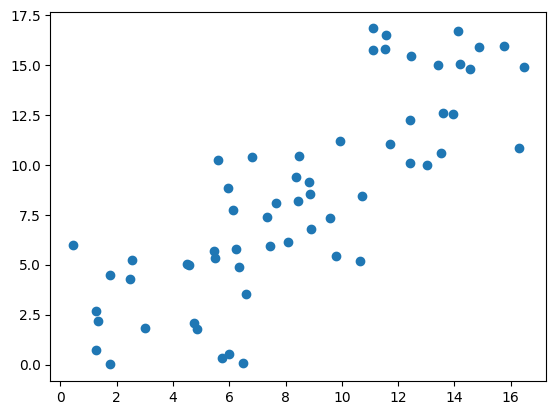

In [247]:
import matplotlib.pyplot as plt
import copy
import numpy as np
from numpy.linalg import norm
from sklearn.cluster import KMeans

loaded_points = np.load('k_mean_points.npy')

plt.figure()
plt.scatter(loaded_points[:,0],loaded_points[:,1])

In [248]:
# number  of k

k = 3

In [249]:

def initialize_clusters(points: np.ndarray, k_clusters: int) -> np.ndarray:
    """
    Initializes and returns k random centroids from the given dataset.

    :param points: Array of data points.
    :type: points ndarray with shape (n, 2)

    :param k_clusters: The number of clusters to form
    :type k_clusters: int


    :return: initial_clusters
    initial_clusters: Array of initialized centroids

    :rtype:
    initial_clusters: np.array (k_clusters, 2)
    :

    """

    ###################################
    # Write your own code here #

    points_copy = np.copy(loaded_points)

    #shuffle the datapoints
    np.random.shuffle(points_copy)

    #assign the clusters
    initial_clusters  = points_copy[:k,:]

    ###################################

    return initial_clusters

In [250]:
def calculate_metric(points: np.ndarray, centroid: np.ndarray) -> np.ndarray:
    """
    Calculates the distance metric between each point and a given centroid.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param centroid: A single centroid
    :type centroid: ndarray with shape (1, 2)

    :return: distances_array
    distances_array: Array of distances from point to centroid

    :rtype:
    distances_array: ndarray with shape (n,)
    :
    """

    ###################################
    # Write your own code here #

    distances_array = np.linalg.norm(points - centroid, axis=1)

    ###################################

    return distances_array

In [251]:
def compute_distances(points: np.ndarray, centroids_points: np.ndarray) -> np.ndarray:
    """
    Computes and returns the distance from each point to each centroid.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param centroids_points: A all centroid points
    :type centroids_points: ndarray with shape (k_clusters, 2)


    :return: distances_array
    distances_array: 2D array with distances of each point to each centroid.

    :rtype:
    distances_array: ndarray of shape (k_clusters, n)
    """
    ###################################
    # Write your own code here #

    distances = []

    for centroid in centroids_points:
      distances_this_centroid = calculate_metric(points,centroid)

      distances.append(distances_this_centroid)

    distances_array = np.array(distances)

    ###################################


    return distances_array

In [252]:
def assign_centroids(distances: np.ndarray) -> np.ndarray:
    """
    Assigns each point to the closest centroid based on the distances.

    Parameters:
    :param distances: 2D array with distances of each point to each centroid.
    :type distances: ndarray with shape (k_clusters, n)

    :return: assigned_clusters
    assigned_clusters: Array indicating the closest centroid for each data point.

    :rtype:
    assigned_centroids: ndarray with shape (1, n) and dtype = np.int32
    """

    ###################################
    # Write your own code here #

    assigned_centroids = np.argmin(distances, axis = 0).astype(np.int32)

    ###################################

    return assigned_centroids.reshape(1,-1)

In [253]:
def calculate_objective(assigned_centroids: np.ndarray, distances: np.ndarray) -> np.ndarray:
    """
    Calculates and returns the objective function value for the clustering.

    Parameters:
    :param assigned_centroids: Array indicating the cluster assignment for each point.
    :type assigned_centroids: ndarray with shape (1, n) and and dtype = np.int64

    :param distances: 2D array with distances of each point to each centroid
    :type distances: ndarray with shape (k_clusters, n) and and dtype = np.float64

    :return: onjective_function_value
    onjective_function_value: Objective function value.

    :rtype:
    onjective_function_value: float32


    """
    ###################################
    # Write your own code here #

    n = distances.shape[1] # number of points

    distances_to_closest_centroid = distances[assigned_centroids[0],np.arange(n)]

    objective_function_value = np.sum(distances_to_closest_centroid ** 2)

    objective_function_value = np.float32(objective_function_value)
    ###################################

    return objective_function_value

In [254]:
def calculate_new_centroids(points: np.ndarray, assigned_centroids: np.ndarray, k_clusters: int) -> np.ndarray:
    """
    Computes new centroids based on the current cluster assignments.

    Parameters:
    :param points: Array of n data points.
    :type points: ndarray with shape (n, 2)

    :param assigned_centroids: Array indicating the closest centroid for each data point.
    :type assigned_centroids: ndarray with shape (1, n) and dtype = np.int32


    :param k_clusters: Number of clusters.
    :type k_clusters: int


    :return: new_clusters
    new_clusters: new cluster points

    :rtype:
    new_clusters: ndarray with shape (1, n) and dtype = np.float32
    """

    ###################################
    # Write your own code here #

    new_clusters = []

    for i in range(k_clusters):
      points_from_i_cluster = points[assigned_centroids[0] == i]

      if len(points_from_i_cluster) == 0:
        # if there is not points for this cluster , reposition him randomly
        random_index = np.random.randint(len(points))
        new_clusters.append(points[random_index])

      else:
        mean = np.mean(points_from_i_cluster, axis=0)
        new_clusters.append(mean)

    ###################################

    return np.array(new_clusters,dtype=np.float32)

In [255]:
def fit(points: np.ndarray, k_clusters: int, n_of_oterations: int, error: float = 0.001) -> tuple:
    """
    Fits the k-means clustering model on the dataset.

    Parameters:
    :param points : Array of data points.
    :type points: ndarray with shape (n, 2) and dtype = np.float32

    :param k_clusters:  Number of clusters
    :type k_clusters: int

    :param n_of_oterations:  Maximum number of iterations
    :type n_of_oterations: int


    :param error: Threshold for convergence.
    :type error: float

    :return: centroid_points, last_objective
    centroid_points: final centroid points
    last_objective: final objective funtion

    :rtype:
    centroid_points: ndarray with shape (k_clusters, 2) and dtype = np.float32
    last_objective: float

    """

    ###################################
    # Write your own code here #

    last_objective = 10000.0

    centroid_points = initialize_clusters(points,k_clusters)

    for _ in range(n_of_oterations):

        distances = compute_distances(points,centroid_points) # calculates distance from each point to each centroid
        assigned_centroids = assign_centroids(distances) # assigns each point to a centroid
        objective_value = calculate_objective(assigned_centroids,distances) # calculates objective

        if abs(last_objective - objective_value) <= error:
          last_objective = objective_value
          break

        last_objective = objective_value #objective updated
        centroid_points = calculate_new_centroids(points,assigned_centroids,k_clusters) # calculate new centroids

    ###################################
    return centroid_points, last_objective

Text(0, 0.5, 'Sum of squared distance')

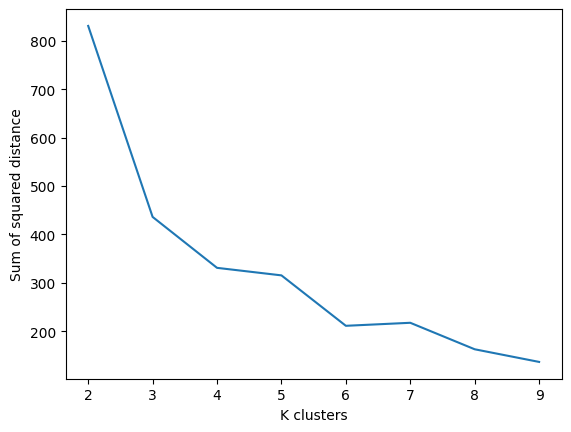

In [256]:
# Exercise 2
k_all = range(2, 10)
all_objective = []


#WRITE YOUR CODE HERE
for i in k_all:
  centroids, objective_value = fit(loaded_points, k_clusters=i, n_of_oterations=50)
  all_objective.append(objective_value)

plt.figure()
plt.plot(k_all, all_objective)
plt.xlabel('K clusters')
plt.ylabel('Sum of squared distance')


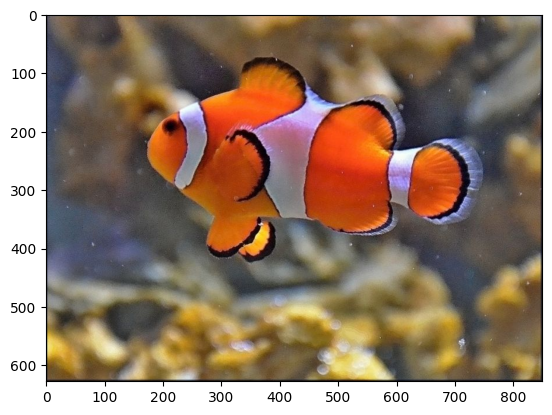

In [257]:
# Exercise 3

from matplotlib.image import imread
from sklearn.cluster import KMeans
import numpy as np

loaded_image = imread('fish.jpg')

plt.imshow(loaded_image)
plt.show()

In [258]:
def compress_image(image: np.ndarray, number_of_colours: int) -> np.ndarray:
    """
    Compresses the given image by reducing the number of colours used in the image.

    This function applies k-means clustering to group the pixel colours of the image
    into 'number_of_colours' clusters. Each pixel's colour in the image is then replaced
    with the colour of the closest centroid of these clusters. This process effectively
    reduces the number of colours in the image, resulting in compression.

    Parameters:
    image (np.array): The original image is represented as a 3D numpy array
                      (height x width x color_channels).
    number_of_colours (int): The number of colours to reduce the image to.

    Returns:
    np.array: The compressed image as a numpy array in the same shape as the input.
    """
    height , width , channels = image.shape

    pixels_2d = np.reshape(image,(height*width,channels))

    kmeans = KMeans(number_of_colours)
    kmeans.fit(pixels_2d)

    print(kmeans.cluster_centers_)
    print(kmeans.labels_)
    pixels_compressed = kmeans.cluster_centers_[kmeans.labels_]

    image_compressed = np.reshape(pixels_compressed,(height,width,channels))

    return image_compressed.astype(np.uint8)

[[ 99.76818951  37.02669675  20.29404023]
 [116.00358695  95.63786416  67.65069552]
 [183.79021668 172.17706281 157.51203764]
 [204.1704236   93.86323752  19.86444781]
 [ 71.21512339  76.15499208  92.37541318]
 [137.75919462 127.67359101 119.48020603]
 [226.27241018 214.58964074 169.91594001]
 [171.36550673 131.12606892  52.18288037]
 [ 85.33387938  91.71308094 112.29765805]
 [181.43927501 155.49079492 110.13572142]
 [ 81.09330184  75.30888071  70.87766024]
 [ 48.79706141  43.4188748   47.88289589]
 [161.91506309  63.03496158  15.67597096]
 [121.29557146 125.35405949 146.13106688]
 [243.68549554  88.54081264  21.27562093]
 [138.78277247 116.5761414   74.97276377]
 [155.65020277 144.23200775 143.30736638]
 [214.17609083 206.31967943 243.59572573]
 [ 31.03677066  13.51529579  16.32526337]
 [158.8948291  135.46017139  92.23897166]
 [244.53365718 133.45824659  31.27365256]
 [104.00281532  79.89977477  49.99808559]
 [ 64.60587881  62.06637754  63.62522588]
 [133.84514675 100.61661186  41.20

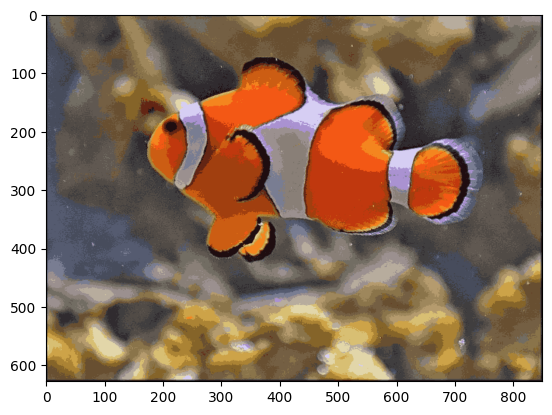

In [259]:
img = compress_image(loaded_image, 30)

plt.figure()
plt.imshow(img)
plt.show()